# Smart Airport Passenger Assistance Multimodal Chatbot

This notebook uses fictional airport knowledge base and is designed to help passengers to navigate airport terminals, security checks, baggage claim and help with airport related queries.

The bot is capable of understanding **text, voice** and **images**.

**Models used:**

**CLIP + FAISS**: Images (airport signs)

**Whisper**: speech to text

**MiniLM + FAISS**: Text

**Streamlit**: User Interface

In [3]:
#Connecting collab to google drive to get access of required files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
#importing python libraries to create file paths and directories and checking if the file exist
import os
import sys

# location where the folder lies
PROJECT_DIR = "/content/drive/MyDrive/airport-assistant"
#defining the data folder by combining folders (audio, text and images)
DATA_DIR = os.path.join(PROJECT_DIR, "data")
#defining evaluation folder that contains evaluation results
EVAL_DIR = os.path.join(PROJECT_DIR, "eval")

#changing the directory to treat PROJECT_DIR as current working folder
os.chdir(PROJECT_DIR)
#adding project folders at the beginning of python search list
sys.path.insert(0, PROJECT_DIR)
#creating evaluation folder if does not exist else do not give error
os.makedirs(EVAL_DIR, exist_ok=True)

#creating config.py and writing project, data and evaluation path
#this helps to use these paths without having to define path again and again
with open("config.py", "w", encoding="utf-8") as f:
    f.write("PROJECT_DIR = " + repr(PROJECT_DIR) + "\n")
    f.write("DATA_DIR = " + repr(DATA_DIR) + "\n")
    f.write("EVAL_DIR = " + repr(EVAL_DIR) + "\n")


#Environment Setup and Checking GPU availability
Since the models used need high computations resources, use GPU.

In [5]:
# Checking if Google Colab has GPU access
import torch

print("System Information:")
print(f"Python version: {os.sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    device = torch.device("cuda")
else:
    print("GPU not available, using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

System Information:
Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch version: 2.11.0+cpu
CUDA available: False
GPU not available, using CPU
Using device: cpu



### Install libraries


In [6]:
#Installing necessary libraries
# library to create user interface
!pip install streamlit
# hugging face library used to run pre-trained models
!pip install transformers
# PyTorch library for image processing
!pip install torch torchvision
# to generate vector embedding from text
!pip install sentence-transformers
# a dependecy of CLIP to clean text
!pip install ftfy
# installing actual CLIP model from OpenAI's source code
!pip install git+https://github.com/openai/CLIP.git
# PIL for opening image files
!pip install pillow
# vision library for images
!pip install opencv-python
# library to read audio files
!pip install soundfile
# library to extract features from audio files
!pip install librosa
# to search matching record from the database
!pip install faiss-cpu
# to operate mathematical functions on arrays
!pip install numpy
# tables and dataframes
!pip install pandas
# to create plots features
!pip install matplotlib
# train test split and metrics
!pip install scikit-learn
# for audio and images
!pip install scipy
# to view streamlit app in web browser from colab
!pip install pyngrok

print("All dependencies installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-dhjqni8m
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-dhjqni8m
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=13a8302eb5fc14bf4cdea2230927ea488f7bafcf98579eda442ef277499b9b95
  Stored in directory: /tmp/pip-ephem-wheel-cache-2vwug6pw/wheels/cb/a8/74/5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 70.5 MB/s eta 0:00:00
All dependencies installed successfully!


In [7]:
#importing necessary libraries
import torch
import torchvision
import transformers
import sentence_transformers
import clip
import cv2
import PIL
import librosa
import soundfile
import faiss
import sklearn
import numpy
import pandas
import matplotlib
import matplotlib.pyplot as plt
import scipy
import streamlit
import pyngrok


## Exploratory Data Analysis

### Airport knowledge base

The knowledge base is a JSON file of a fictional airport and is not a live data.

In [8]:
# importing json library to read json file
import json
# importing csv library to read csv file
import csv
# importing image module from Pillow to process image files like jpeg
from PIL import Image
import pandas as pd

# creating a path to knwoledge base, opening, loading and reading json file located at kb_path
kb_path = os.path.join(DATA_DIR, "kb", "airport_kb.json")
with open(kb_path, "r", encoding="utf-8") as f:
    kb = json.load(f)

#printing number and fields of records from the file
print("Number of records:", len(kb))
print("Fields in one record:", list(kb[0].keys()))
print()
#printing an example of record in the file
print("Example record:")
print(" id:", kb[0]["id"])
print(" name:", kb[0]["name"])
print(" category:", kb[0]["category"])
print(" terminal:", kb[0]["terminal"])
print(" description:", kb[0]["description"])
print(" opening_hours:", kb[0]["opening_hours"])
print(" direction_text:", kb[0]["direction_text"])
print(" accessibility:", kb[0]["accessibility"])
print(" related_facilities:", kb[0]["related_facilities"])
print(" assistance_contact:", kb[0]["assistance_contact"])

Number of records: 25
Fields in one record: ['id', 'name', 'category', 'terminal', 'floor_or_zone', 'description', 'opening_hours', 'direction_text', 'accessibility', 'related_facilities', 'assistance_contact']

Example record:
 id: gate_b12
 name: Gate B12
 category: gate
 terminal: 1
 description: Boarding gate B12 is used for many international flights in Terminal 1.
 opening_hours: Follows flight schedule. Staffed about 2 hours before departure.
 direction_text: From check-in, go through security. Follow signs for pier B. Gate B12 is about 8 minutes walk.
 accessibility: Step-free route. Seating and a wheelchair waiting point are next to the gate.
 related_facilities: ['restroom', 'coffee shop', 'information desk']
 assistance_contact: Special assistance desk, Terminal 1 arrivals, phone +44 0000 111 201


gate                  3
check_in              2
baggage               2
security              2
information           2
restaurant            2
lost_and_found        1
lounge                1
prayer_room           1
transport             1
taxi                  1
special_assistance    1
restroom              1
pharmacy              1
first_aid             1
currency_exchange     1
car_rental            1
parking               1
Name: count, dtype: int64


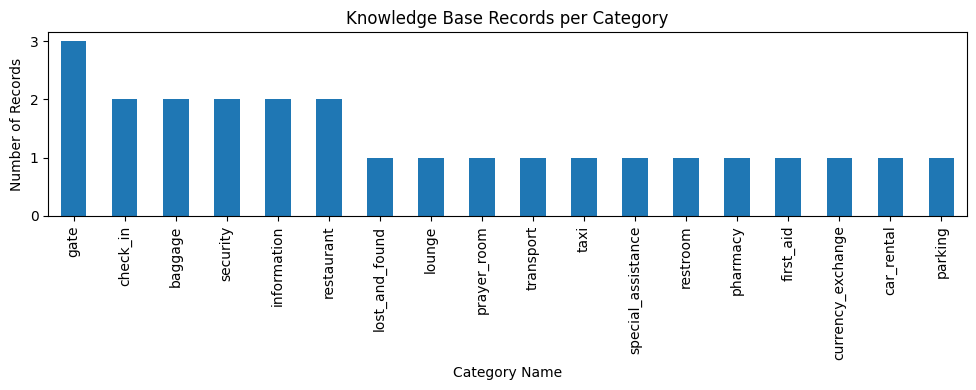

In [9]:
# Analysis and visualization of knowledge base records
# Go through each row to get the category and store as a list
kb_categories = [row["category"] for row in kb]
# count the number of records in each category
kb_counts = pd.Series(kb_categories).value_counts()

print(kb_counts)

# presenting the records of each category in bar diagram
plt.figure(figsize=(10, 4))
kb_counts.plot(kind="bar")
plt.title("Knowledge Base Records per Category")
plt.xlabel("Category Name")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


### Labelled images

The images are in `data/images/downloaded`. Images are public domain pictograms.

Licenses are in `data/images/sources.csv`.

In [10]:
#Analysis of image folder
# creating a path to the image folder
image_dir = os.path.join(DATA_DIR, "images", "downloaded")
manifest_path = os.path.join(DATA_DIR, "images", "manifest.csv")

#creating an empty list where CSV file can be stored in each row
image_rows = []
with open(manifest_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        image_rows.append(row)

# printing the number of images and the first five rows stored in image_rows
print("Number of labelled images:", len(image_rows))
print("First 5 rows:")
for row in image_rows[:5]:
    print(row)


Number of labelled images: 28
First 5 rows:
{'filename': 'aiga_arriving.png', 'category': 'gate'}
{'filename': 'aiga_departing.png', 'category': 'gate'}
{'filename': 'aiga_baggage.png', 'category': 'baggage'}
{'filename': 'aiga_ticket.png', 'category': 'check_in'}
{'filename': 'aiga_customs.png', 'category': 'security'}


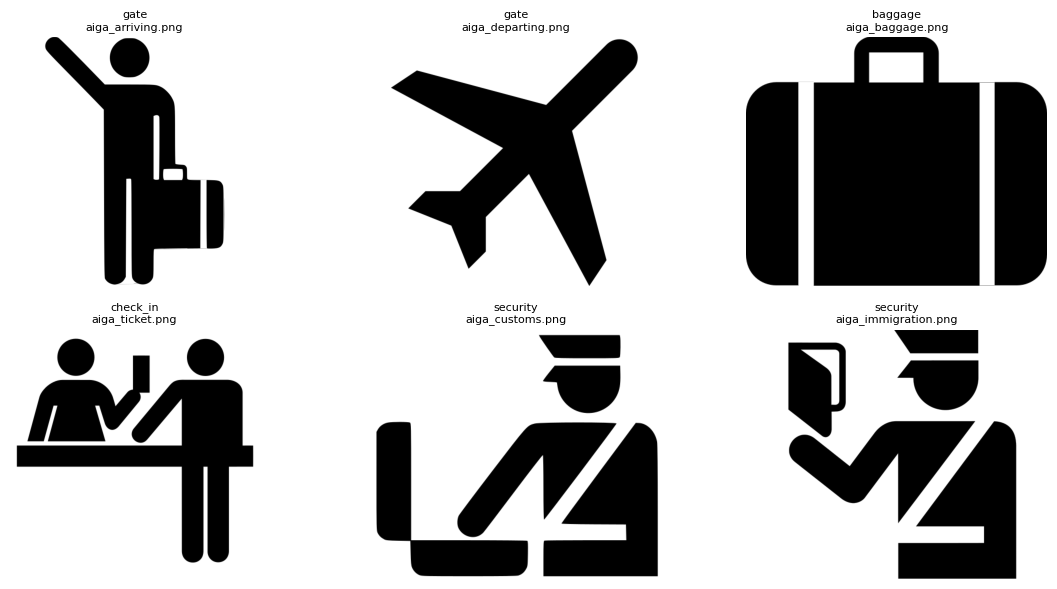

In [11]:
# Displaying either all or upto 4 images from the image file whoichever is lower
show_n = min(6, len(image_rows))
plt.figure(figsize=(12, 6))
for i in range(show_n):
    row = image_rows[i]
    img_path = os.path.join(image_dir, row["filename"])
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(row["category"] + "\n" + row["filename"], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


information          7
security             3
restroom             3
transport            3
gate                 2
restaurant           2
taxi                 1
check_in             1
baggage              1
lost_and_found       1
first_aid            1
currency_exchange    1
car_rental           1
parking              1
Name: count, dtype: int64


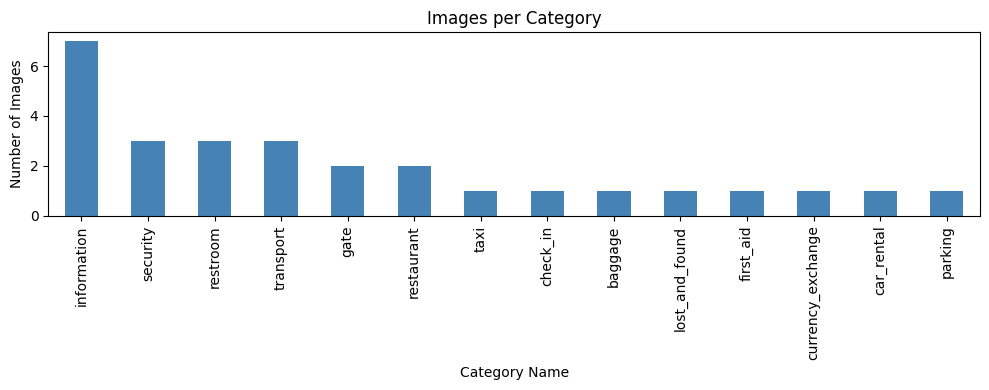

In [12]:
#Analysis and visualization of image records
# Go through each row to get the category and store as a list
image_cats = [row["category"] for row in image_rows]
# count the number of records in each category
img_counts = pd.Series(image_cats).value_counts()
print(img_counts)

# presenting the records of each category in bar diagram
plt.figure(figsize=(10, 4))
img_counts.plot(kind="bar", color="steelblue")
plt.title("Images per Category")
plt.xlabel("Category Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


### Similar vs different signs

Creating a controlled image comparison with examples of similar and different images. This is used for image-text and image-image semantic similarity in CLIP.

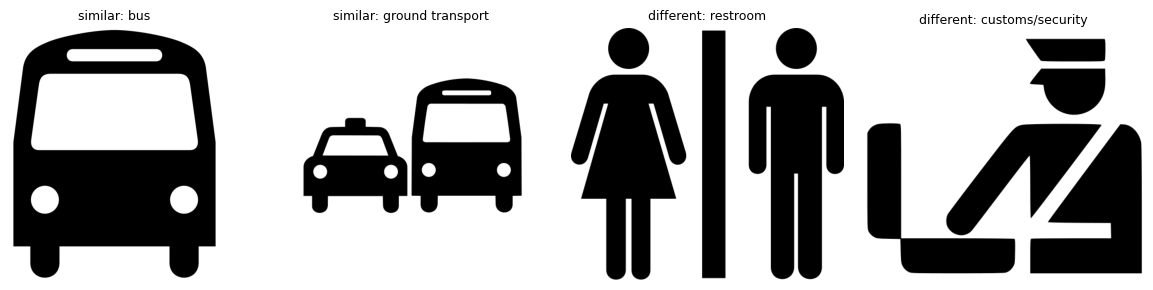

In [13]:
# defining a function show_named and creating the image path of exact location
def show_named(filename, title, subplot_n):
    path = os.path.join(image_dir, filename)
    if not os.path.exists(path):
        print("Missing", filename)
        return
    #opening and loading the image and converting it into RGB format
    img = Image.open(path)
    plt.subplot(1, 4, subplot_n)
    plt.imshow(img)
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.figure(figsize=(12, 3))
show_named("aiga_bus.png", "similar: bus", 1)
show_named("aiga_ground.png", "similar: ground transport", 2)
show_named("toilets_unisex.png", "different: restroom", 3)
show_named("aiga_customs.png", "different: customs/security", 4)
plt.tight_layout()
plt.show()


### Voice and text data

Text queries are in `passenger_queries.json`  

Audio files are in `data/audio/tts` . Audio files are computer voices and not real human voices.


In [14]:
#creating a path to text query json file located in the data folder
queries_path = os.path.join(DATA_DIR, "text", "passenger_queries.json")
#opening and reading the json file
with open(queries_path, "r", encoding="utf-8") as f:
    queries = json.load(f)

#displaying number of text queries and examples
print("Number of text queries:", len(queries))
print("Example:")
print(queries[0])
print(queries[2])

#displaying entities from text queries examples
print("\nExamples of Entities:")
for q in queries[:8]:
    print(q["text"], "->", q["entities"])

Number of text queries: 40
Example:
{'id': 1, 'text': 'Where is gate B12?', 'intent': 'find_gate', 'entities': {'gate_number': 'B12'}}
{'id': 3, 'text': 'I need directions to gate C8 in terminal 2', 'intent': 'find_gate', 'entities': {'gate_number': 'C8', 'terminal_number': '2'}}

Examples of Entities:
Where is gate B12? -> {'gate_number': 'B12'}
How do I get to gate A5? -> {'gate_number': 'A5'}
I need directions to gate C8 in terminal 2 -> {'gate_number': 'C8', 'terminal_number': '2'}
Which pier is gate B12 on? -> {'gate_number': 'B12'}
How do I get to baggage claim? -> {}
Where is the baggage reclaim in terminal 1? -> {'terminal_number': '1'}
My suitcase is on the carousel, which hall? -> {}
Where is the check in desk for international flights? -> {}


find_gate            4
baggage              3
opening_hours        3
transport            3
check_in             2
security             2
lounge               2
information          2
delay                2
taxi                 2
restroom             2
accessibility        2
lost_and_found       2
restaurant           2
prayer_room          2
currency_exchange    1
car_rental           1
parking              1
pharmacy             1
first_aid            1
Name: count, dtype: int64


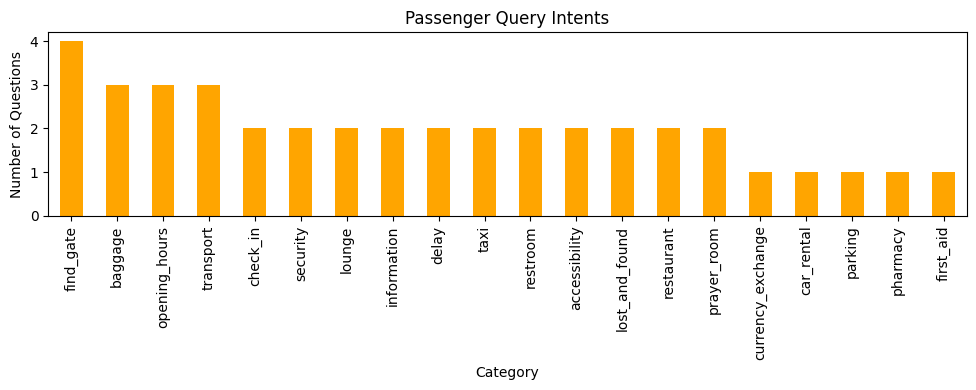

Total tokens: 274
Unique tokens: 112
Some words: ['1', '2', 'a', 'a5', 'accessible', 'after', 'aid', 'airport', 'am', 'an', 'and', 'are', 'ask', 'assistance', 'b12', 'bag', 'baggage', 'bags', 'bus', 'c8']


In [15]:
#Analysis and visualization of passenger queries
# count the number of queries per intent
intent_counts = pd.Series([q["intent"] for q in queries]).value_counts()
print(intent_counts)

#displaying the queries counts in bar graph
plt.figure(figsize=(10, 4))
intent_counts.plot(kind="bar", color="orange")
plt.title("Passenger Query Intents")
plt.xlabel("Category")
plt.ylabel("Number of Questions")
plt.tight_layout()
plt.show()

#creating an empty list where words from passengers queries are stored
all_words = []
for q in queries:
    #converties each query into different words by converting each alphabet into lower case and removing , and ?
    words = q["text"].lower().replace("?", "").replace(",", "").split()
    all_words.extend(words)

#printing total number of words in the list
print("Total tokens:", len(all_words))
#printing unique words or tokens in the list
print("Unique tokens:", len(set(all_words)))
#printing first 20 words in the list
print("Some words:", sorted(set(all_words))[:20])


In [16]:
#Loading text to speech dataset
#creating a path to Text to speech audio files
tts_dir = os.path.join(DATA_DIR, "audio", "tts")
#defining the path to csv file where audio and text are associated
script_path = os.path.join(DATA_DIR, "audio", "tts_scripts.csv")

#creating and empty list where rows are filled from the csv file
tts_rows = []
#opening and reading csv file
with open(script_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        tts_rows.append(row)

#printing the text from audio file and length of the audio
print("Audio files:")
for row in tts_rows:
    path = os.path.join(tts_dir, row["filename"])
    #check if the audio files exist, if yes, load the file through librosa using 16KHz sampling rate and if not print missing instead of giving error
    if os.path.exists(path):
        y, sr = librosa.load(path, sr=16000, mono=True)
        seconds = len(y) / 16000
        print(row["filename"], "|", row["text"], "|", round(seconds, 2), "sec")
    else:
        print("missing", row["filename"])


Audio files:
tts_gate_b12.mp3 | Where is gate B12? | 2.04 sec
tts_baggage.mp3 | How do I get to baggage claim? | 2.4 sec
tts_checkin.mp3 | Where is the check in desk for international flights? | 3.6 sec
tts_lounge.mp3 | Is there a lounge near terminal 2? | 2.76 sec
tts_transport.mp3 | Where can I find airport transport? | 3.0 sec
tts_info.mp3 | Where is the nearest information desk? | 2.93 sec
tts_delay.mp3 | Is my flight delayed? | 1.85 sec
tts_assist.mp3 | I need wheelchair help | 1.92 sec


## Preprocessing

In [17]:
%%writefile image_pipeline.py
# image preprocessing- preparing images to provide them to CLIP in the expected format.

import numpy as np
from PIL import Image
import torchvision.transforms as T

#CLIP mean values for RGB respectively to normalize the CLIP images
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
#CLIP standard deviation values for RGB respectively to normalize the CLIP images
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

#defining a function to load images from the path
def load_image(path):
    # PIL opens the file. convert("RGB") as CLIP expects 3 channels images and it even applies for Black and white images
    image = Image.open(path).convert("RGB")
    return image

#defining a function called resize_image to convert the image size as per the requirement of the CLIP. CLIP was trained on 224*224 image size and even if size=224 is not defined, it will take 224 as default value.
def resize_image(image, size=224):
    return image.resize((size, size), Image.Resampling.BILINEAR)

#defining a function called augment_image to make small changes in the image brightness, contrast and saturations to create variations of the images.
#This helpes the model to be more robust to different versions of images.
def augment_image(image):
    aug = T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2)
    return aug(image)

#definind a function to convert images into the tensors format used by PyTorch tensor
def image_to_tensor(image, normalise=True):
    #converting pixels from 0-255 into 0-1 and Height*Width*Channels to Channels*Height*Width
    to_tensor = T.ToTensor()
    tensor = to_tensor(image)
    if normalise:
        tensor = T.Normalize(CLIP_MEAN, CLIP_STD)(tensor)
    return tensor

#defining function to preprocess the images and call previously defined functions
def preprocess_image(path, augment=False):
    image = load_image(path)
    image = resize_image(image)
    if augment:
        image = augment_image(image)
    tensor = image_to_tensor(image, normalise=True)
    return tensor

#defining a function to convert back from tensor to image
def tensor_to_image(tensor):
    # undoing CLIP normalise to disply the results. Tensor cloning is performed not to modify original tensor the tensorso we can plt.imshow the result. Undoing everthing done in previous steps.
    img = tensor.detach().cpu().clone()
    mean = np.array(CLIP_MEAN).reshape(3, 1, 1)
    std = np.array(CLIP_STD).reshape(3, 1, 1)
    arr = img.numpy() * std + mean
    #forcing values to remain between 0 and 1 to avoid invalid image values
    arr = np.clip(arr, 0, 1)
    #converts back from Channels*Height*Width to Height*Width*Channels
    arr = np.transpose(arr, (1, 2, 0))
    #converts backs from 0-1 to 0-255
    arr = (arr * 255).astype(np.uint8)
    #return back from numpy to PIL image
    return Image.fromarray(arr)

Overwriting image_pipeline.py


In [18]:
%%writefile audio_pipeline.py
# audio preprocessing- preparing audio to provide them to Whisper in the expected format.

import librosa
import torch


#defining function to load audio file from the path. The desired sampling rate(sr) is 16000 samples per second
def load_audio(path, sr=16000):
    # loading audio using librosa which converts audio into waveforms (numbers) and returns it along with sampling rate.
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

#defining a function to trim the start and end of session with no audio. The threshold for the audio is 25 decibels.
def trim_audio(y, top_db=25):
    y_trim, _ = librosa.effects.trim(y, top_db=top_db)
    #checking if the trimmed audio is empty, if yes then return to orgigial audio
    if len(y_trim) == 0:
        return y
    return y_trim

#defining a function to extract MFCC features. (MFCC are the numerical features to represent characteristics of audio)
def get_mfcc(y, sr=16000, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc

#Creating main class to handle audio analysis
class WhisperTranscriber:
    #Set up the processor and choose the hardware
    def __init__(self, model_name="openai/whisper-tiny", device='cuda'):
        from transformers import WhisperProcessor, WhisperForConditionalGeneration
        self.device = device
        print("Loading Whisper:", model_name, "on", device)
        #Load the tool that prepares audio for the model
        self.processor = WhisperProcessor.from_pretrained(model_name)
        #Load the actual AI model that understands speech
        self.model = WhisperForConditionalGeneration.from_pretrained(model_name)
        # Move the model to the GPU memory
        self.model.to(device)
        # Set the model to 'evaluation mode'
        self.model.eval()

    #defining function to transcribe the audio words into text
    def transcribe(self, path):
        y, sr = load_audio(path, sr=16000)
        y = trim_audio(y)
        #preparing the audio for the model at a standard speed
        inputs = self.processor(y, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(self.device)
        #model is not learning here
        with torch.no_grad():
            #generating numerical codes of the audio
            predicted_ids = self.model.generate(input_features)
            #converting back codes into human language
            text = self.processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
        return text.strip()

Overwriting audio_pipeline.py


In [19]:
%%writefile text_pipeline.py
# text preprocessing- preparing text by normalizing text, semantic embeddings

import json
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

#defining list of stop words
STOPWORDS = {
    "a", "an", "the", "is", "are", "am", "was", "were", "be", "been",
    "i", "you", "he", "she", "it", "we", "they", "my", "your",
    "do", "does", "did", "can", "could", "will", "would", "should",
    "to", "of", "in", "on", "at", "for", "and", "or", "there",
}

# gate like b12 or B12 (letter + 1 to 3 digits)
GATE_PATTERN = re.compile(r"\b([a-z]\d{1,3})\b")
TERMINAL_PATTERN = re.compile(r"terminal\s?(\d)")

#defining function to convert all words into strings and lower case, remove punctuations, and removes spaces at the start and end of word as well as multiple spaces in between. This cleans the texts.
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

#defining function to convert texts into individual word tokes.
def tokenize(text):
    cleaned = clean_text(text)
    tokens = cleaned.split()
    return tokens

#defining function to remove stopwords as listed in STOPWORDS
def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOPWORDS]

#defining function to identify and extract entities from passengers queries
def extract_entities(text):
    cleaned = clean_text(text)
    entities = {}
    gate_match = GATE_PATTERN.search(cleaned)
    if gate_match:
        entities["gate_number"] = gate_match.group(1).upper()
    terminal_match = TERMINAL_PATTERN.search(cleaned)
    if terminal_match:
        entities["terminal_number"] = terminal_match.group(1)
    return entities

#defining function to split data into train and validation data
def split_data(queries, test_size=0.2, random_state=42):
    intents = [q["intent"] for q in queries]
    try:
        train_data, val_data = train_test_split(
            queries,
            test_size=test_size,
            random_state=random_state,
            stratify=intents,
        )
    except ValueError:
        print("Stratify did not work since there are too little examples for some intents. Hence, normal split is performed.")
        train_data, val_data = train_test_split(
            queries,
            test_size=test_size,
            random_state=random_state,
        )
    return train_data, val_data

#defining function to convert text into vectors to perform embeddings
def tfidf_embeddings(texts):
    cleaned = [clean_text(t) for t in texts]
    vectorizer = TfidfVectorizer()
    matrix = vectorizer.fit_transform(cleaned)
    return vectorizer, matrix

#defining function to conduct semantic embedding using allMiniLM to capture word similarity
def minilm_embeddings(texts):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    cleaned = [clean_text(t) for t in texts]
    vectors = model.encode(cleaned, convert_to_numpy=True)
    return vectors

#defining function to load passenger queries json file
def load_queries(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

Overwriting text_pipeline.py


### Image pipeline

In [20]:
#importing functions created in image_pipeline
from image_pipeline import load_image, resize_image, augment_image, image_to_tensor, tensor_to_image

#creating paths to baggage photo and way finding photo from downloaded folder in the data
icon_path = os.path.join(DATA_DIR, "images", "downloaded", "aiga_baggage.png")
photo_path = os.path.join(DATA_DIR, "images", "downloaded", "photo_wayfinding.jpg")

#loading the images by the defined function load_image
icon = load_image(icon_path)
photo = load_image(photo_path)

#printing the width and height of both the images
print("Icon size:", icon.size)
print("Photo size:", photo.size)

#resizing images using function resize_image
icon_small = resize_image(icon)
photo_small = resize_image(photo)
#augmenting only the way finding photo
photo_aug = augment_image(photo_small)

print("After resize:", icon_small.size)

#converting image to tensor for the baggage icon
icon_tensor = image_to_tensor(icon_small)
print("Tensor shape (C, H, W):", tuple(icon_tensor.shape))


Icon size: (500, 414)
Photo size: (3264, 2448)
After resize: (224, 224)
Tensor shape (C, H, W): (3, 224, 224)


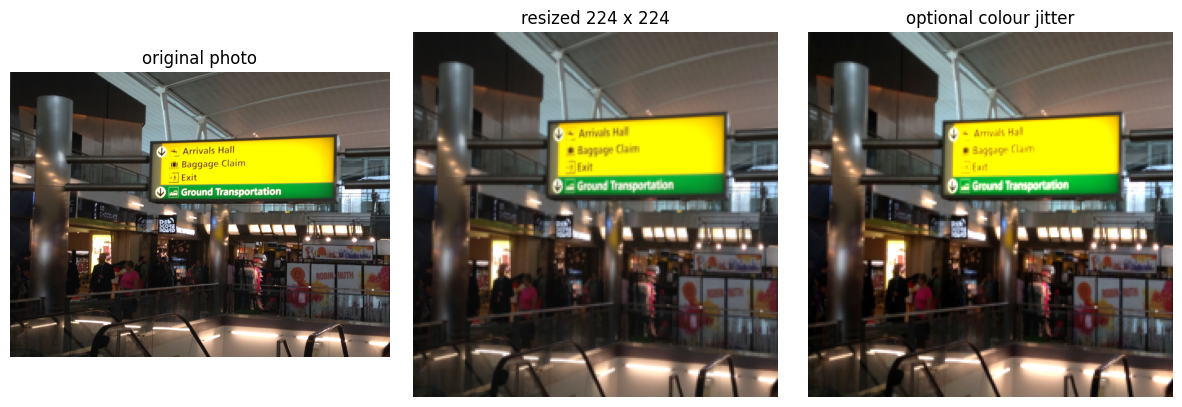

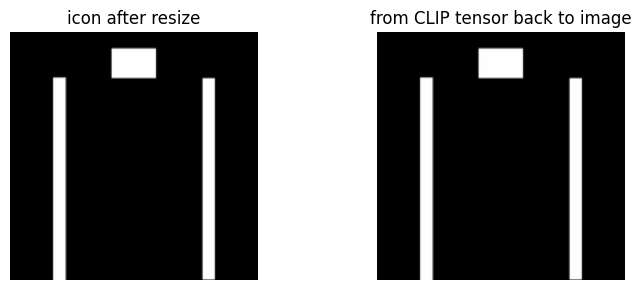

In [21]:
#plotting photo image and icon image of both aiga_baggage.png and photo_wayfinding.jpg
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(photo)
plt.title("original photo")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(photo_small)
plt.title("resized 224 x 224")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(photo_aug)
plt.title("optional colour jitter")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(icon_small)
plt.title("icon after resize")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tensor_to_image(icon_tensor))
plt.title("from CLIP tensor back to image")
plt.axis("off")
plt.tight_layout()
plt.show()


### Audio pipeline

Sample rate: 16000
Seconds before trim: 2.04
Seconds after trim: 1.47
MFCC shape: (13, 47)


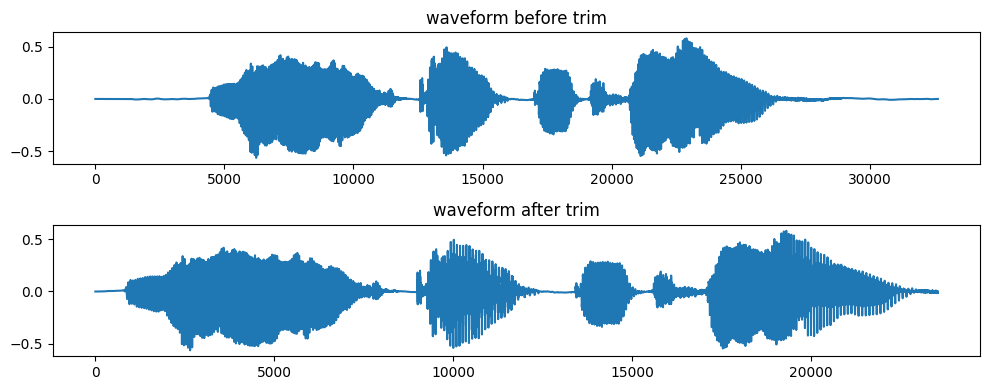

In [22]:
#importing functions created in audio_pipeline
from audio_pipeline import load_audio, trim_audio, get_mfcc, WhisperTranscriber

#creating a path to audio file, loading the file and triming it to remove silent part at start and end of audio
audio_path = os.path.join(DATA_DIR, "audio", "tts", "tts_gate_b12.mp3")
y, sr = load_audio(audio_path)
y_trim = trim_audio(y)

print("Sample rate:", sr)
print("Seconds before trim:", round(len(y) / sr, 2))
print("Seconds after trim:", round(len(y_trim) / sr, 2))

mfcc = get_mfcc(y_trim, sr)
print("MFCC shape:", mfcc.shape)

#displaying the audio waveform before and after triming
plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(y)
plt.title("waveform before trim")
plt.subplot(2, 1, 2)
plt.plot(y_trim)
plt.title("waveform after trim")
plt.tight_layout()
plt.show()

In [23]:
whisper = WhisperTranscriber(model_name="openai/whisper-tiny", device=device)

#defining path to the audio file that needs to be transcribed
demo_audio = os.path.join(DATA_DIR, "audio", "tts", "tts_gate_b12.mp3")
from_whisper = whisper.transcribe(demo_audio)
print("tts_gate_b12.mp3 ->", from_whisper)

Loading Whisper: openai/whisper-tiny on cpu


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece token

tts_gate_b12.mp3 -> Where is gate 12?


### Text pipeline

In [24]:
#importing all the functions created in text_pipeline
from text_pipeline import clean_text, tokenize, remove_stopwords, extract_entities, split_data, tfidf_embeddings, load_queries

#loading the passenger queries by creating a path to json file
queries = load_queries(os.path.join(DATA_DIR, "text", "passenger_queries.json"))
print("Number of queries:", len(queries))

#printing examples of queries before and after cleaning text
example = queries[2]["text"]
print("Original:", example)
print("Cleaned:", clean_text(example))
#displaying example of individual tokes
print("Tokens:", tokenize(example))
print("Without stopwords:", remove_stopwords(tokenize(example)))
print("Entities:", extract_entities(example))

train_data, val_data = split_data(queries)
print("Train size:", len(train_data))
print("Val size:", len(val_data))

all_texts = [q["text"] for q in queries]
vectorizer, matrix = tfidf_embeddings(all_texts)
print("TF-IDF matrix shape:", matrix.shape)


Number of queries: 40
Original: I need directions to gate C8 in terminal 2
Cleaned: i need directions to gate c8 in terminal 2
Tokens: ['i', 'need', 'directions', 'to', 'gate', 'c8', 'in', 'terminal', '2']
Without stopwords: ['need', 'directions', 'gate', 'c8', 'terminal', '2']
Entities: {'gate_number': 'C8', 'terminal_number': '2'}
Stratify did not work since there are too little examples for some intents. Hence, normal split is performed.
Train size: 32
Val size: 8
TF-IDF matrix shape: (40, 108)


### System Overview

Visual AI matches uploaded sign photos to our database, while text AI matches passenger questions to airport records.

In [25]:
%%writefile vision_search.py

import os
import csv
import numpy as np
import torch
from PIL import Image
import faiss
import clip

#defining class to handle airport image analysis
class ImageSearcher:
    # Set up the processor and choose the hardware (CPU or GPU)
    def __init__(self, data_dir, device=None):
        if device == None:
            device = "cuda" if torch.cuda.is_available() else "cpu"
        #save the hardware choice
        self.device = device
        #store the data directory
        self.data_dir = data_dir
        #creating path to image directory
        self.image_dir = os.path.join(data_dir, "images", "downloaded")
        #creating path to manifest.csv
        self.manifest_path = os.path.join(data_dir, "images", "manifest.csv")

        print("Loading CLIP ViT-B/32 on", device)
        #load the CLIP model and preprocessing function
        self.model, self.preprocess = clip.load("ViT-B/32", device=device)
        # Set the model to 'evaluation mode' (not training mode)
        self.model.eval()
        self.build_index()

    #defining function to encode images
    def encode_image_file(self, path):
        image = Image.open(path).convert("RGB")
        #applying CLIP preprocessing and prepares image for CLIP model
        tensor = self.preprocess(image).unsqueeze(0).to(self.device)
        # Tell the model not to learn right now (saves memory)
        with torch.no_grad():
            #converting images into numerical vectors
            features = self.model.encode_image(tensor)
        features = features.float()
        #normalize the vectors
        features = features / features.norm(dim=-1, keepdim=True)
        return features

    #defining a function build FAISS index and create searchable images
    def build_index(self):
        #creating an empty list which can store rows from manifest.csv
        rows = []
        #open and read each row
        with open(self.manifest_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                rows.append(row)

        #creates list to store CLIP embedding, image names and categories
        vectors = []
        self.filenames = []
        self.categories = []

        #going through each rows in a loop for image embedding
        for row in rows:
            path = os.path.join(self.image_dir, row["filename"])
            if not os.path.exists(path):
                print("Missing image (skip):", row["filename"])
                continue
            features = self.encode_image_file(path)
            #converts tensor into Numpy
            vectors.append(features.cpu().numpy()[0])
            #stores image filenames and categories
            self.filenames.append(row["filename"])
            self.categories.append(row["category"])

        matrix = np.stack(vectors).astype("float32")
        d = matrix.shape[1]
        self.index = faiss.IndexFlatIP(d)
        self.index.add(matrix)
        print("Image FAISS size:", self.index.ntotal)

    #defining a function to search the images
    #k=3 shows 3 most similar images
    def search_image(self, path, k=3):
        features = self.encode_image_file(path)
        #converting Pytorch to Numpy float array
        q = features.cpu().numpy().astype("float32")
        #asking FAISS to look for top (k numbers) similar images
        scores, idx = self.index.search(q, k)
        i = int(idx[0][0])
        top = []
        #loop through top 3 results and store the filenames, categories and similarity scores
        for rank in range(len(idx[0])):
            j = int(idx[0][rank])
            top.append({
                "filename": self.filenames[j],
                "category": self.categories[j],
                "score": float(scores[0][rank]),
            })
        #return the results
        return {
            "filename": self.filenames[i],
            "category": self.categories[i],
            "score": float(scores[0][0]),
            "embedding": features,
            "top_k": top,
        }

    #defining function to compare the image with the knolwedge base to find the most similar image
    def pick_kb_record(self, kb, category, image_features):
        #search through knowledge base and keeps the category that matches with the image category
        rows = [r for r in kb if r["category"] == category]
        #if no matching record then print no record
        if len(rows) == 0:
            print("No KB record for category:", category)
            return None
        #if matching record is found then return the row
        if len(rows) == 1:
            return rows[0]

        texts = []
        for rec in rows:
            texts.append("a photo of " + rec["name"] + ". " + rec["description"])
        #tokenize the records in knowledge base
        tokens = clip.tokenize(texts, truncate=True).to(self.device)
        # Tell the model not to learn right now (saves memory)
        with torch.no_grad():
            text_features = self.model.encode_text(tokens)
        text_features = text_features.float()
        #normalizing text embedding
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        #calculating text and image similarity
        sims = (text_features @ image_features.T).squeeze(1)
        i = int(torch.argmax(sims).item())
        return rows[i]

Overwriting vision_search.py


In [26]:
%%writefile text_search.py

import os
import json
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

from text_pipeline import clean_text, extract_entities


# creating a blueprint to handle searching for airport information
class TextSearcher:
    # setting up the initial steps and loading the airport data
    def __init__(self, data_dir):
        self.data_dir = data_dir
        kb_path = os.path.join(data_dir, "kb", "airport_kb.json")
        # opening and reading the airport knowledge file
        with open(kb_path, "r", encoding="utf-8") as f:
            self.kb = json.load(f)

        # creating an empty list to hold text descriptions
        self.docs = []
        # going through each record and combining its text fields
        for rec in self.kb:
            text = rec["name"] + " " + rec["category"] + " " + rec["description"] + " " + rec["direction_text"]
            self.docs.append(text)

        print("Loading MiniLM all-MiniLM-L6-v2")
        # loading the model that understands text meaning
        self.model = SentenceTransformer("all-MiniLM-L6-v2")
        # cleaning the text and converting it into numerical patterns
        cleaned = [clean_text(t) for t in self.docs]
        vectors = self.model.encode(cleaned, convert_to_numpy=True)
        # adjusting the patterns for accurate comparison
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        vectors = vectors / norms
        self.vectors = vectors.astype("float32")
        # creating a fast search database for text
        d = self.vectors.shape[1]
        self.index = faiss.IndexFlatIP(d)
        # adding all text patterns to the database
        self.index.add(self.vectors)
        print("Text FAISS size:", self.index.ntotal)
        print("KB records:", len(self.kb))

    # defining a function to convert a typed question into numbers
    def encode_query(self, query):
        q = clean_text(query)
        vec = self.model.encode([q], convert_to_numpy=True)
        vec = vec / np.linalg.norm(vec, axis=1, keepdims=True)
        return vec.astype("float32")

    # defining a function to check if the user is asking about a specific gate
    def gate_record(self, entities):
        # returning nothing if no gate is mentioned
        if "gate_number" not in entities:
            return None
        gate = entities["gate_number"]
        # looking through all airport records to find the matching gate
        for rec in self.kb:
            blob = (rec["id"] + " " + rec["name"]).upper()
            if gate.upper() in blob:
                return rec
        return None

    # defining a function to find the best answer for a user question
    def search_text(self, query, k=3, category=None):
        # extracting key details like gate numbers from the question
        entities = extract_entities(query)
        gate_rec = self.gate_record(entities)
        # converting the question into numbers
        vec = self.encode_query(query)

        # if a gate was found, return its record directly with a high score
        if gate_rec is not None:
            i = self.kb.index(gate_rec)
            score = float(np.dot(vec[0], self.vectors[i]))
            top = [{"name": gate_rec["name"], "score": score, "category": gate_rec["category"]}]
            return gate_rec, score, entities, top

        # if no specific category is needed, search all records
        if category is None:
            # asking the database for the best matching records
            scores, idx = self.index.search(vec, k)
            i = int(idx[0][0])
            top = []
            # gathering the details of the top matches
            for rank in range(len(idx[0])):
                j = int(idx[0][rank])
                top.append({
                    "name": self.kb[j]["name"],
                    "category": self.kb[j]["category"],
                    "score": float(scores[0][rank]),
                })
            # returning the best match
            return self.kb[i], float(scores[0][0]), entities, top

        # if a category is given, only search within that category
        best_i = None
        best_score = -1.0
        top = []
        # comparing the question to each record in the category
        for i, rec in enumerate(self.kb):
            if rec["category"] != category:
                continue
            score = float(np.dot(vec[0], self.vectors[i]))
            top.append({"name": rec["name"], "category": rec["category"], "score": score})
            # keeping track of the highest scoring match
            if score > best_score:
                best_score = score
                best_i = i
        # sorting matches from best to worst
        top = sorted(top, key=lambda x: x["score"], reverse=True)[:k]
        # if no matches are found in the category, search everything
        if best_i is None:
            print("No KB rows in category", category, "- searching all records")
            return self.search_text(query, k=k, category=None)
        # returning the best match found in the category
        return self.kb[best_i], best_score, entities, top

Overwriting text_search.py


In [27]:
%%writefile fusion.py

from text_search import TextSearcher
from vision_search import ImageSearcher
from audio_pipeline import WhisperTranscriber

# setting the lowest acceptable match score
MIN_SCORE = 0.30

# creating a main blueprint to combine text, voice, and image answers
class AirportAssistant:
    # setting up the search tools and loading the models
    def __init__(self, data_dir, device=None):
        self.data_dir = data_dir
        print("Building text index...")
        self.text_searcher = TextSearcher(data_dir)
        print("Building image index...")
        self.image_searcher = ImageSearcher(data_dir, device=device)
        print("Loading Whisper tiny...")
        self.whisper = WhisperTranscriber(device=device)

        # finding the information desk record to use as a backup answer
        self.info_desk = self.text_searcher.kb[0]
        for rec in self.text_searcher.kb:
            if rec["id"] == "info_t1":
                self.info_desk = rec
                break

    # defining a backup response when the system is not sure
    def refuse(self, mode, score, transcript=None):
        if score is None:
            score = 0.0
        # preparing a friendly message directing the user to the information desk
        return {
            "mode": mode,
            "matched": False,
            "score": round(float(score), 3),
            "name": None,
            "category": None,
            "description": None,
            "direction_text": None,
            "opening_hours": None,
            "accessibility": None,
            "assistance_contact": self.info_desk["assistance_contact"],
            "transcript": transcript,
            "message": "I do not get your question. Please ask a person at the information desk.",
        }

    # defining a successful response when a match is found
    def from_record(self, rec, mode, score, transcript=None):
        # gathering all the details of the matching record to show the user
        return {
            "mode": mode,
            "matched": True,
            "score": round(float(score), 3),
            "name": rec["name"],
            "category": rec["category"],
            "description": rec["description"],
            "direction_text": rec["direction_text"],
            "opening_hours": rec["opening_hours"],
            "accessibility": rec["accessibility"],
            "assistance_contact": rec["assistance_contact"],
            "transcript": transcript,
            "message": None,
        }

    # defining the main function to handle user input
    def answer(self, text=None, image_path=None, audio_path=None):
        transcript = None
        # checking if a voice recording was provided and converting it to text
        if audio_path is not None:
            transcript = self.whisper.transcribe(audio_path)
            # combining typed text and spoken text if both exist
            if text is None or str(text).strip() == "":
                text = transcript
            else:
                text = str(text) + " " + transcript

        has_text = text is not None and str(text).strip() != ""
        has_image = image_path is not None

        # if neither text nor image is provided, return the backup response
        if (not has_text) and (not has_image):
            return self.refuse("none", 0.0)

        # if both image and text are provided, search both and combine scores
        if has_image and has_text:
            if audio_path is not None:
                mode = "image+voice"
            else:
                mode = "image+text"
            image_hit = self.image_searcher.search_image(image_path)
            rec, text_score, entities, _ = self.text_searcher.search_text(
                text, category=image_hit["category"]
            )
            score = 0.5 * image_hit["score"] + 0.5 * text_score
            if score < MIN_SCORE:
                return self.refuse(mode, score, transcript)
            return self.from_record(rec, mode, score, transcript)

        # if only an image is provided, search based on the image
        if has_image:
            image_hit = self.image_searcher.search_image(image_path)
            rec = self.image_searcher.pick_kb_record(
                self.text_searcher.kb,
                image_hit["category"],
                image_hit["embedding"],
            )
            if rec is None or image_hit["score"] < MIN_SCORE:
                return self.refuse("image", image_hit["score"])
            return self.from_record(rec, "image", image_hit["score"])

        # if only text or voice is provided, search based on the text
        if audio_path is not None:
            mode = "voice"
        else:
            mode = "text"
        rec, score, entities, _ = self.text_searcher.search_text(text)
        # returning the final answer or backup response based on the score
        if score < MIN_SCORE:
            return self.refuse(mode, score, transcript)
        return self.from_record(rec, mode, score, transcript)


# defining a shortcut tool to easily use the main answering blueprint
def answer(assistant, text=None, image_path=None, audio_path=None):
    return assistant.answer(text=text, image_path=image_path, audio_path=audio_path)

Overwriting fusion.py


This downloads the AI tools and sets up the image and text databases for quick searching.


In [28]:
import importlib
import fusion
# forcing the system to reload our custom file just in case we made recent changes
importlib.reload(fusion)

# picking out the specific blueprints, tools, and limits we need from our custom file
from fusion import AirportAssistant, answer, MIN_SCORE

print("Refuse below MIN_SCORE =", MIN_SCORE)

# starting up the main assistant and giving it the folder where our files are saved
assistant = AirportAssistant(DATA_DIR, device=device)

print("Ready.")

Refuse below MIN_SCORE = 0.3
Building text index...
Loading MiniLM all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Text FAISS size: 25
KB records: 25
Building image index...
Loading CLIP ViT-B/32 on cpu


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 130MiB/s]


Image FAISS size: 28
Loading Whisper tiny...
Loading Whisper: openai/whisper-tiny on cpu


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Ready.


###Image Search
Uploaded photos are matched against our saved images to find the correct category. Note that visual answers alone cannot always tell Terminal 1 and Terminal 2 apart.


Query file: aiga_baggage.png
Nearest gallery file: aiga_baggage.png
Predicted category: baggage
CLIP similarity: 1.0
Top 3:
  aiga_baggage.png baggage 1.0
  aiga_arriving.png gate 0.953
  aiga_lostfound.png lost_and_found 0.913


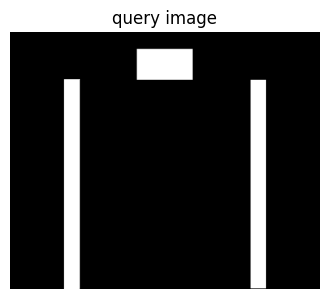

In [29]:
# defining the exact location of a specific sample image to use as a test
query_image = os.path.join(DATA_DIR, "images", "downloaded", "aiga_baggage.png")

# asking the assistant to find the most similar images from its database
hit = assistant.image_searcher.search_image(query_image)

print("Query file: aiga_baggage.png")
print("Nearest gallery file:", hit["filename"])
print("Predicted category:", hit["category"])
print("CLIP similarity:", round(hit["score"], 3))
# printing a list of the top three closest matches and their scores
print("Top 3:")
for row in hit["top_k"]:
    print(" ", row["filename"], row["category"], round(row["score"], 3))

# setting up a small window to display the original test image on the screen
plt.figure(figsize=(4, 4))
plt.imshow(load_image(query_image))
plt.title("query image")

# hiding the grid lines and borders around the image so it looks clean
plt.axis("off")

# showing the final image on the screen
plt.show()


###Text Search
The passenger's question is simplified, and specific details like gate numbers are automatically picked out.

In [30]:
# defining a sample question a passenger might ask
typed = "Where is gate B12?"

# asking the assistant to find the top three closest matches for the typed question
rec, score, entities, top = assistant.text_searcher.search_text(typed, k=3)

print("Query:", typed)
print("Top-1:", rec["name"], "score", round(score, 3))
print("Top 3:")
# going through each of the top three matches one by one
for row in top:
    print(" ", row["name"], round(row["score"], 3))


Query: Where is gate B12?
Top-1: Gate B12 score 0.639
Top 3:
  Gate B12 0.639


###One Tool for Everything
The system uses one main command to process and reply to any mix of text, voice, and image inputs.

In [31]:
# defining a tool to display the assistant's answer clearly on the screen
def show(reply):
    print(json.dumps(reply, indent=2))
    print()

# finding the exact location of a baggage sign image to use as a test
img_bag = os.path.join(DATA_DIR, "images", "downloaded", "aiga_baggage.png")

# finding the exact location of an information sign image to use as a test
img_info = os.path.join(DATA_DIR, "images", "downloaded", "aiga_info.png")

# finding the exact location of a voice recording asking about a gate
wav_gate = os.path.join(DATA_DIR, "audio", "tts", "tts_gate_b12.mp3")

# finding the exact location of a voice recording asking about baggage
wav_bag = os.path.join(DATA_DIR, "audio", "tts", "tts_baggage.mp3")

print("=== text only ===")
show(answer(assistant, text="Where is gate B12?"))

print("=== voice only ===")
show(answer(assistant, audio_path=wav_gate))

print("=== image only ===")
show(answer(assistant, image_path=img_bag))

print("=== image + text ===")
show(answer(assistant, text="Where do I collect my suitcase in terminal 1?", image_path=img_bag))

print("=== image + voice ===")
show(answer(assistant, image_path=img_info, audio_path=wav_bag))


=== text only ===
{
  "mode": "text",
  "matched": true,
  "score": 0.639,
  "name": "Gate B12",
  "category": "gate",
  "description": "Boarding gate B12 is used for many international flights in Terminal 1.",
  "direction_text": "From check-in, go through security. Follow signs for pier B. Gate B12 is about 8 minutes walk.",
  "opening_hours": "Follows flight schedule. Staffed about 2 hours before departure.",
  "accessibility": "Step-free route. Seating and a wheelchair waiting point are next to the gate.",
  "assistance_contact": "Special assistance desk, Terminal 1 arrivals, phone +44 0000 111 201",
  "transcript": null,
  "message": null
}

=== voice only ===
{
  "mode": "voice",
  "matched": true,
  "score": 0.499,
  "name": "Gate B12",
  "category": "gate",
  "description": "Boarding gate B12 is used for many international flights in Terminal 1.",
  "direction_text": "From check-in, go through security. Follow signs for pier B. Gate B12 is about 8 minutes walk.",
  "opening_hou

###Handling Off-Topic Questions
The system will not make up answers for non-airport questions. It will safely direct the passenger to the information desk instead.

In [32]:
print("=== uncertain / fail ===")
# asking a question that has nothing to do with the airport to see if the assistant safely refuses to answer
show(answer(assistant, text="What is the capital of France and who won the football?"))

=== uncertain / fail ===
{
  "mode": "text",
  "matched": false,
  "score": 0.062,
  "name": null,
  "category": null,
  "description": null,
  "direction_text": null,
  "opening_hours": null,
  "accessibility": null,
  "assistance_contact": "Information desk T1, phone +44 0000 111 100",
  "transcript": null,
  "message": "I do not get your question. Please ask a person at the information desk."
}



## 5. System Testing
Here we test the accuracy of the image matching, voice recognition, and text searches using small sample sets. These scores are meant to evaluate this specific project and are not large-scale, official industry benchmarks.

In [33]:
# printing out the system setup details, including the active helper, the storage folder, and the total number of items saved in both databases
print("Using assistant:", type(assistant).__name__)
print("Eval folder:", EVAL_DIR)
print("Image FAISS size:", assistant.image_searcher.index.ntotal)
print("Text FAISS size:", assistant.text_searcher.index.ntotal)

Using assistant: AirportAssistant
Eval folder: /content/drive/MyDrive/airport-assistant/eval
Image FAISS size: 28
Text FAISS size: 25


### Image Testing
Testing an image against itself would unfairly result in a perfect score. Instead, we hide the test image and force the system to search the rest of the gallery. A success means it found the correct category (like matching "baggage" to "baggage").


In [34]:
import numpy as np

# pulling all the saved image patterns out of the database and arranging them into a single grid
searcher = assistant.image_searcher
n = searcher.index.ntotal
d = searcher.index.d

matrix = np.zeros((n, d), dtype="float32")
for i in range(n):
    matrix[i] = searcher.index.reconstruct(i)

# creating an empty list to record the test results
vision_rows = []

# testing every image one by one to see if the system can find its closest match without cheating (ignoring the exact same image)
for i in range(n):
    q = matrix[i]
    scores = matrix.dot(q)
    scores[i] = -999.0
    order = np.argsort(-scores)

    # checking if the system's top guess or its top three guesses belong to the correct category
    top1 = int(order[0])
    top3 = [int(order[j]) for j in range(3)]
    true_cat = searcher.categories[i]
    pred_cat = searcher.categories[top1]
    in_top3 = true_cat in [searcher.categories[j] for j in top3]

    # saving the details of how well the system did on this specific image
    vision_rows.append({
        "filename": searcher.filenames[i],
        "true_category": true_cat,
        "pred_top1": pred_cat,
        "in_top3": in_top3,
        "score": round(float(scores[top1]), 3),
        "top1_file": searcher.filenames[top1],
    })

# organizing all the results into a table and calculating the overall success rate
vision_df = pd.DataFrame(vision_rows)
top1_acc = (vision_df["true_category"] == vision_df["pred_top1"]).mean()
top3_acc = vision_df["in_top3"].mean()

# displaying the total number of tested images, the final scores, and the detailed breakdown on the screen
print("Images:", n)
print("Leave-one-out top-1 category accuracy:", round(top1_acc, 3))
print("Leave-one-out top-3 category accuracy:", round(top3_acc, 3))
print()
print(vision_df[["filename", "true_category", "pred_top1", "in_top3", "score"]].to_string(index=False))

# saving the final test report to a file so it can be reviewed later
vision_path = os.path.join(EVAL_DIR, "vision_metrics.csv")
vision_df.to_csv(vision_path, index=False)
print()
print("Saved", vision_path)

Images: 28
Leave-one-out top-1 category accuracy: 0.321
Leave-one-out top-3 category accuracy: 0.357

             filename     true_category   pred_top1  in_top3  score
    aiga_arriving.png              gate     baggage    False  0.953
   aiga_departing.png              gate    check_in    False  1.000
     aiga_baggage.png           baggage        gate    False  0.953
      aiga_ticket.png          check_in        gate    False  1.000
     aiga_customs.png          security        gate    False  1.000
 aiga_immigration.png          security        gate    False  0.893
        aiga_info.png       information information     True  0.949
   aiga_hotelinfo.png       information information     True  0.949
        aiga_taxi.png              taxi   transport    False  0.933
      aiga_ground.png         transport        taxi     True  0.933
        aiga_rail.png         transport   transport     True  0.916
         aiga_bus.png         transport   transport     True  0.916
  aiga_restaur

A success means the system's very first guess is the right category. Note that real-world photos are harder for the system to identify than simple graphics.


Example hits:
            filename true_category   pred_top1  score
       aiga_info.png   information information  0.949
  aiga_hotelinfo.png   information information  0.949
       aiga_rail.png     transport   transport  0.916
        aiga_bus.png     transport   transport  0.916
photo_wayfinding.jpg   information information  0.877

Misses:
            filename     true_category   pred_top1            top1_file  score
   aiga_arriving.png              gate     baggage     aiga_baggage.png  0.953
  aiga_departing.png              gate    check_in      aiga_ticket.png  1.000
    aiga_baggage.png           baggage        gate    aiga_arriving.png  0.953
     aiga_ticket.png          check_in        gate   aiga_departing.png  1.000
    aiga_customs.png          security        gate   aiga_departing.png  1.000
aiga_immigration.png          security        gate    aiga_arriving.png  0.893
       aiga_taxi.png              taxi   transport      aiga_ground.png  0.933
     aiga_ground.png 

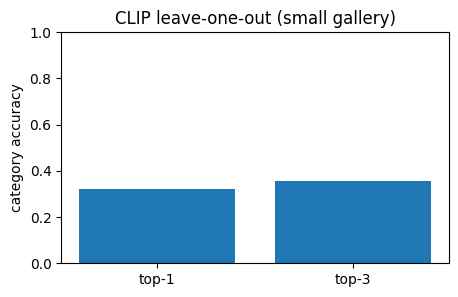

In [35]:
# separating the test results into a group of correct guesses and a group of incorrect guesses
hits = vision_df[vision_df["true_category"] == vision_df["pred_top1"]]
misses = vision_df[vision_df["true_category"] != vision_df["pred_top1"]]

# showing a few examples where the system guessed the image category perfectly
print("Example hits:")
print(hits.head(5)[["filename", "true_category", "pred_top1", "score"]].to_string(index=False))
print()

# displaying the mistakes the system made, or printing a message if it got everything right
print("Misses:")
if len(misses) == 0:
    print("(none on this run)")
else:
    print(misses[["filename", "true_category", "pred_top1", "top1_file", "score"]].to_string(index=False))

# creating a small bar chart to visually display how often the system was right on its first try versus its top three tries
plt.figure(figsize=(5, 3))
plt.bar(["top-1", "top-3"], [top1_acc, top3_acc])
plt.ylim(0, 1)
plt.ylabel("category accuracy")
plt.title("CLIP leave-one-out (small gallery)")
plt.show()

### Voice Testing
The voice tool is tested by cleaning up the text and counting the number of mistaken words to calculate an error score. For these tests, we use clean, computer-generated voices rather than real passengers in a loud airport.

tts_gate_b12.mp3
  ref: Where is gate B12?
  hyp: Where is gate 12?
  WER: 0.25

tts_baggage.mp3
  ref: How do I get to baggage claim?
  hyp: How do I get to baggage claim?
  WER: 0.0

tts_checkin.mp3
  ref: Where is the check in desk for international flights?
  hyp: Where is the check-in desk for international flight?
  WER: 0.333

tts_lounge.mp3
  ref: Is there a lounge near terminal 2?
  hyp: Is there a lounge near Terminal 2?
  WER: 0.0

tts_transport.mp3
  ref: Where can I find airport transport?
  hyp: Where can I find airport transport?
  WER: 0.0

tts_info.mp3
  ref: Where is the nearest information desk?
  hyp: Where is the nearest information desk?
  WER: 0.0

tts_delay.mp3
  ref: Is my flight delayed?
  hyp: is my flight delayed.
  WER: 0.0

tts_assist.mp3
  ref: I need wheelchair help
  hyp: I need wheelchair help.
  WER: 0.0

Mean WER: 0.073
Saved /content/drive/MyDrive/airport-assistant/eval/speech_metrics.csv


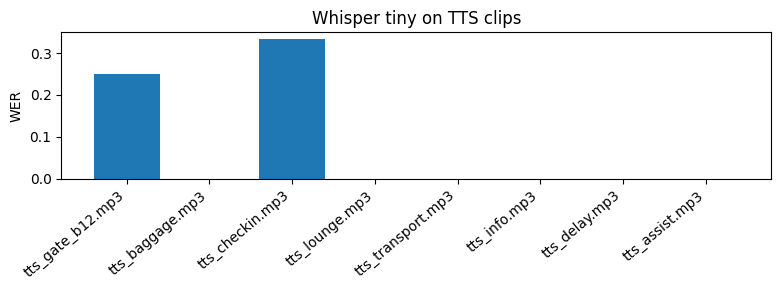

In [36]:
# defining tools to calculate the error rate by counting the mismatched words between the correct text and the assistant's guess
def word_distance(ref_words, hyp_words):
    n = len(ref_words)
    m = len(hyp_words)
    dp = np.zeros((n + 1, m + 1), dtype=int)
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if ref_words[i - 1] == hyp_words[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost,
            )
    return int(dp[n][m])

def simple_wer(ref, hyp):
    r = clean_text(ref).split()
    h = clean_text(hyp).split()
    if len(r) == 0:
        if len(h) == 0:
            return 0.0
        return 1.0
    return word_distance(r, h) / len(r)


# loading the test data, having the assistant listen to each audio file, and recording its error score
scripts_path = os.path.join(DATA_DIR, "audio", "tts_scripts.csv")
tts_rows = []
with open(scripts_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        tts_rows.append(row)

speech_rows = []
for row in tts_rows:
    path = os.path.join(DATA_DIR, "audio", "tts", row["filename"])
    hyp = assistant.whisper.transcribe(path)
    ref = row["text"]
    wer = simple_wer(ref, hyp)
    speech_rows.append({
        "filename": row["filename"],
        "reference": ref,
        "hypothesis": hyp,
        "wer": round(wer, 3),
    })
    print(row["filename"])
    print("  ref:", ref)
    print("  hyp:", hyp)
    print("  WER:", round(wer, 3))
    print()


# calculating the overall average score and saving the detailed test results to a file
speech_df = pd.DataFrame(speech_rows)
print("Mean WER:", round(speech_df["wer"].mean(), 3))

speech_path = os.path.join(EVAL_DIR, "speech_metrics.csv")
speech_df.to_csv(speech_path, index=False)
print("Saved", speech_path)


# building and displaying a bar chart to visually show how many mistakes were made on each recording
plt.figure(figsize=(8, 3))
plt.bar(speech_df["filename"], speech_df["wer"])
plt.xticks(rotation=40, ha="right")
plt.ylabel("WER")
plt.title("Whisper tiny on TTS clips")
plt.tight_layout()
plt.show()

### Text Testing
The system is tested against 40 sample questions it has never seen before. A correct answer means it found the right category, and for gate questions, it must also identify the exact gate number. A few complex topics (like opening hours or delays) are adjusted manually for the test.

Number of labelled queries: 40
This is the full list, not an extra hold-out split.

Text retrieval accuracy (category, plus gate id when present): 0.825

Wrong or expected-hard rows:
 id      intent expected_category                       pred_name pred_category  score
  7     baggage           baggage Restrooms Terminal 1 departures      restroom  0.274
 12    security          security                        Gate B12          gate  0.466
 17   transport         transport                Car rental desks    car_rental  0.455
 19 information       information                  First aid room     first_aid  0.397
 20       delay         NO_RECORD        Terminal 2 check-in area      check_in  0.282
 21       delay         NO_RECORD        Terminal 1 check-in area      check_in  0.137
 23        taxi              taxi                Car rental desks    car_rental  0.503

Saved /content/drive/MyDrive/airport-assistant/eval/text_metrics.csv


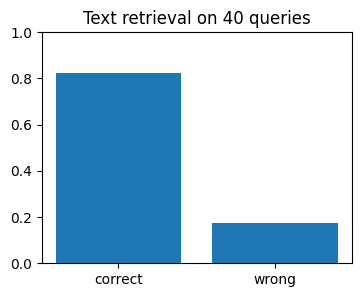

In [37]:
# setting up a cheat sheet to match what the user wants with the correct categories in the database, and loading all the test questions
INTENT_TO_CAT = {
    "find_gate": "gate",
    "baggage": "baggage",
    "check_in": "check_in",
    "security": "security",
    "lounge": "lounge",
    "transport": "transport",
    "information": "information",
    "taxi": "taxi",
    "restroom": "restroom",
    "accessibility": "special_assistance",
    "lost_and_found": "lost_and_found",
    "restaurant": "restaurant",
    "prayer_room": "prayer_room",
    "currency_exchange": "currency_exchange",
    "car_rental": "car_rental",
    "parking": "parking",
    "pharmacy": "pharmacy",
    "first_aid": "first_aid",
    "delay": "NO_RECORD",
    "opening_hours": "mixed",
}

HOURS_EXPECTED = {
    10: "check_in",
    39: "information",
    40: "transport",
}

queries = load_queries(os.path.join(DATA_DIR, "text", "passenger_queries.json"))
print("Number of labelled queries:", len(queries))
print("This is the full list, not an extra hold-out split.")
print()


# testing every question to see if the assistant finds the right category, and double-checking that it catches specific details like gate numbers
text_rows = []
for q in queries:
    rec, score, entities, top = assistant.text_searcher.search_text(q["text"])
    intent = q["intent"]
    if intent == "opening_hours":
        expected = HOURS_EXPECTED.get(q["id"], "information")
    else:
        expected = INTENT_TO_CAT.get(intent, "unknown")

    pred_cat = rec["category"]
    cat_ok = (expected != "NO_RECORD") and (pred_cat == expected)

    gate_ok = True
    if "gate_number" in q.get("entities", {}):
        gate = q["entities"]["gate_number"].upper()
        blob = (rec["id"] + " " + rec["name"]).upper()
        gate_ok = gate in blob

    correct = cat_ok and gate_ok
    if expected == "NO_RECORD":
        correct = False

    text_rows.append({
        "id": q["id"],
        "text": q["text"],
        "intent": intent,
        "expected_category": expected,
        "pred_name": rec["name"],
        "pred_category": pred_cat,
        "score": round(float(score), 3),
        "correct": correct,
    })


# calculating the final accuracy score, saving the results, and creating a chart to show how many questions were answered correctly versus incorrectly
text_df = pd.DataFrame(text_rows)
acc = text_df["correct"].mean()
print("Text retrieval accuracy (category, plus gate id when present):", round(acc, 3))
print()
print("Wrong or expected-hard rows:")
bad = text_df[text_df["correct"] == False]
print(bad[["id", "intent", "expected_category", "pred_name", "pred_category", "score"]].to_string(index=False))

text_path = os.path.join(EVAL_DIR, "text_metrics.csv")
text_df.to_csv(text_path, index=False)
print()
print("Saved", text_path)

plt.figure(figsize=(4, 3))
plt.bar(["correct", "wrong"], [acc, 1 - acc])
plt.ylim(0, 1)
plt.title("Text retrieval on 40 queries")
plt.show()

### Fusion cases

We do a quick check with six examples to see how the system handles combined inputs. This covers the five required combinations and one off-topic scenario.


In [38]:
# locating the sample image and audio files needed for testing
img_bag = os.path.join(DATA_DIR, "images", "downloaded", "aiga_baggage.png")
wav_gate = os.path.join(DATA_DIR, "audio", "tts", "tts_gate_b12.mp3")
wav_bag = os.path.join(DATA_DIR, "audio", "tts", "tts_baggage.mp3")

# creating a list of test scenarios with different combinations of text, voice, and images, along with the expected correct answers
cases = [
    {
        "label": "text only",
        "expected": "gate",
        "kwargs": {"text": "Where is gate B12?"},
        "should_match": True,
    },
    {
        "label": "voice only",
        "expected": "gate",
        "kwargs": {"audio_path": wav_gate},
        "should_match": True,
    },
    {
        "label": "image only",
        "expected": "baggage",
        "kwargs": {"image_path": img_bag},
        "should_match": True,
    },
    {
        "label": "image + text",
        "expected": "baggage",
        "kwargs": {"text": "Where do I collect my suitcase in terminal 1?", "image_path": img_bag},
        "should_match": True,
    },
    {
        "label": "image + voice",
        "expected": "baggage",
        "kwargs": {"image_path": img_bag, "audio_path": wav_bag},
        "should_match": True,
    },
    {
        "label": "refuse",
        "expected": "refuse",
        "kwargs": {"text": "What is the capital of France and who won the football?"},
        "should_match": False,
    },
]

# creating an empty list to collect the results of our tests
fusion_rows = []

# going through each test scenario one by one
for case in cases:
    # asking the assistant to answer the current test scenario
    reply = answer(assistant, **case["kwargs"])

    # extracting the category the assistant guessed
    pred_cat = reply["category"]

    # checking if the assistant found a matching record
    matched = reply["matched"]

    # evaluating if the assistant's answer was completely correct based on our expectations
    if case["should_match"]:
        correct = matched and (pred_cat == case["expected"])
    else:
        correct = (matched is False)

    # recording all the details of this specific test run
    fusion_rows.append({
        "mode": reply["mode"],
        "label": case["label"],
        "expected": case["expected"],
        "predicted_name": reply["name"],
        "predicted_category": pred_cat,
        "score": reply["score"],
        "matched": matched,
        "correct": correct,
    })

    # printing the result of the current test to the screen
    print(case["label"], "->", reply["name"], "score", reply["score"], "matched", matched, "correct", correct)

# organizing all the recorded test results into a structured table
fusion_df = pd.DataFrame(fusion_rows)
print()

# displaying the full table of results
print(fusion_df.to_string(index=False))
print()

# printing the final score to show how many tests the assistant passed
print("Fusion cases correct:", int(fusion_df["correct"].sum()), "/", len(fusion_df))

# defining where to save the test results
fusion_path = os.path.join(EVAL_DIR, "fusion_metrics.csv")

# saving the table of results into a file for future review
fusion_df.to_csv(fusion_path, index=False)
print("Saved", fusion_path)

text only -> Gate B12 score 0.639 matched True correct True
voice only -> Gate B12 score 0.499 matched True correct True
image only -> Terminal 1 baggage claim score 1.0 matched True correct True
image + text -> Terminal 1 baggage claim score 0.744 matched True correct True
image + voice -> Terminal 2 baggage claim score 0.731 matched True correct True
refuse -> None score 0.062 matched False correct True

       mode         label expected           predicted_name predicted_category  score  matched  correct
       text     text only     gate                 Gate B12               gate  0.639     True     True
      voice    voice only     gate                 Gate B12               gate  0.499     True     True
      image    image only  baggage Terminal 1 baggage claim            baggage  1.000     True     True
 image+text  image + text  baggage Terminal 1 baggage claim            baggage  0.744     True     True
image+voice image + voice  baggage Terminal 2 baggage claim           

In [39]:
# listing out all the saved test report files and their sizes to confirm everything was stored correctly
print("Files in eval/:")
for name in os.listdir(EVAL_DIR):
    path = os.path.join(EVAL_DIR, name)
    print(" ", name, "bytes", os.path.getsize(path))

Files in eval/:
  vision_metrics.csv bytes 1869
  speech_metrics.csv bytes 710
  text_metrics.csv bytes 4064
  fusion_metrics.csv bytes 452


## 6. Prototype and ethics

This starts the web app and creates a public link for testing. To protect privacy, user uploads are instantly deleted. The app also displays safety warnings, reminding users not to upload faces or boarding passes.

In [42]:
%%writefile app.py

import os
import sys
import tempfile
import string
import streamlit as st

ROOT = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, ROOT)
os.chdir(ROOT)

from config import PROJECT_DIR, DATA_DIR
from fusion import AirportAssistant, answer, MIN_SCORE

# checking if the data folder exists, showing an error if it is missing
if not os.path.exists(DATA_DIR):
    st.error("I cannot find the data folder on Google Drive:")
    st.code(DATA_DIR)
    st.write("Mount Drive, check PROJECT_DIR in the notebook, then run the setup cell again.")
    st.stop()

# defining a function to format the answer nicely for the screen
def spoken_reply(reply):
    # returning a simple error message if no match was found
    if not reply["matched"]:
        text = "I do not get your question.\n\n"
        text += "Please ask a person at the information desk."
        return text

    # building a clean display with names, descriptions, and directions
    name = reply["name"]
    text = f"### {name}\n"

    if reply.get("description"):
        text += f"*{reply['description']}*\n\n"
    if reply.get("direction_text"):
        text += f"**How to get there:** {reply['direction_text']}\n\n"
    if reply.get("opening_hours"):
        text += f"**Opening hours:** {reply['opening_hours']}\n\n"
    if reply.get("accessibility"):
        text += f"**Access:** {reply['accessibility']}\n\n"
    if reply.get("assistance_contact"):
        text += f"**Need a person?** {reply['assistance_contact']}\n\n"
    return text

# defining a function to temporarily save uploaded files
def save_upload(file_obj, fallback_name):
    if file_obj is None:
        return None
    name = getattr(file_obj, "name", fallback_name)
    # getting the file extension and saving it temporarily
    suffix = os.path.splitext(name)[1]
    if suffix == "":
        suffix = os.path.splitext(fallback_name)[1]
        if suffix == "":
            suffix = ".bin"
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=suffix)
    tmp.write(file_obj.getbuffer())
    tmp.close()
    return tmp.name

# defining the main sequence for processing a single question
def run_turn(text, image_file, audio_file, recorded):
    tmp_paths = []
    image_path = None
    audio_path = None
    try:
        # saving uploaded images or voice recordings
        if image_file is not None:
            image_path = save_upload(image_file, "sign.png")
            tmp_paths.append(image_path)

        audio_src = recorded
        audio_name = "record.wav"
        if audio_src is not None:
            audio_path = save_upload(audio_src, audio_name)
            tmp_paths.append(audio_path)

        # getting the user's typed question
        q = text if text is not None and str(text).strip() != "" else None

        # checking if the user is just saying hello or thank you
        if q is not None and image_path is None and audio_path is None:
            clean_q = q.lower().translate(str.maketrans('', '', string.punctuation)).strip()

            # returning a friendly greeting if they say hi
            if clean_q in ["hi", "hello", "hey", "greetings", "hiya", "good morning", "good afternoon", "good evening"]:
                return {
                    "matched": True,
                    "name": "Hello! 👋",
                    "description": "I am your smart multimodal assistant. I can help you find gates, baggage claim, or services around the airport. What can I help you find today?",
                    "direction_text": None,
                    "opening_hours": None,
                    "accessibility": None,
                    "assistance_contact": None,
                    "score": 1.0,
                    "mode": "Text",
                    "transcript": None
                }

            # returning a polite sign-off if they say thanks
            if clean_q in ["thanks", "thank you", "thx", "thanks a lot", "thank you very much", "appreciate it", "perfect thanks", "ok thanks"]:
                return {
                    "matched": True,
                    "name": "You're very welcome! ✈️",
                    "description": "I'm glad I could help you navigate Kathmandu International Airport. Have a wonderful flight and a safe journey!",
                    "direction_text": None,
                    "opening_hours": None,
                    "accessibility": None,
                    "assistance_contact": None,
                    "score": 1.0,
                    "mode": "Text",
                    "transcript": None
                }

        # if it's a real question, running the search tools to get an answer
        reply = answer(assistant, text=q, image_path=image_path, audio_path=audio_path)
        return reply
    finally:
        # making sure to delete temporary files so they don't take up space
        for path in tmp_paths:
            if path is not None and os.path.exists(path):
                os.remove(path)


# setting up the look of the web page
st.set_page_config(page_title="Airport Assistant", layout="wide", initial_sidebar_state="collapsed")

# adding a large custom title to the top of the page
st.markdown(
    """
    <div style="text-align: center; padding-bottom: 20px;">
        <h1 style="font-size: 4.5rem; font-weight: 700; color: #1E3A8A; line-height: 1.0; margin: 0; padding: 0;">
            Kathmandu International Airport
        </h1>
        <p style="font-size: 1.5rem; color: #64748B; margin-top: 10px;">
            Smart Multimodal Passenger Assistant
        </p>
    </div>
    """,
    unsafe_allow_html=True
)
st.divider()

# defining a tool to load the models once so the app doesn't freeze
@st.cache_resource
def load_assistant():
    print("Loading models for Streamlit...")
    return AirportAssistant(DATA_DIR)

# loading the assistant models
assistant = load_assistant()

# setting up memory to remember the chat history and scores
if "messages" not in st.session_state:
    st.session_state.messages = [
        {
            "role": "assistant",
            "text": "Hello. I am a Smart Airport Assistant. I can help you navigate the airport security, terminal, gates and also help you with signs. \n\nType a question, or use the **Attach / Record** button below to upload a sign photo or record your voice.",
            "image": None,
        }
    ]
if "latest_score" not in st.session_state:
    st.session_state.latest_score = 0.0
if "latest_transcript" not in st.session_state:
    st.session_state.latest_transcript = None
if "latest_mode" not in st.session_state:
    st.session_state.latest_mode = "None"

# creating a two-column layout for the chat and analytics
chat_col, analytics_col = st.columns([7, 3], gap="large")

# setting up the right side of the screen for system information
with analytics_col:
    st.markdown("### System Analytics")

    # showing the match score
    st.metric(label="Retrieval Confidence Score",
              value=f"{st.session_state.latest_score:.3f}",
              delta=f"Threshold: {MIN_SCORE}",
              delta_color="off")

    # showing the input type
    st.markdown(f"**Input Modality Detected:** `{st.session_state.latest_mode}`")

    # showing the transcribed voice text if available
    if st.session_state.latest_transcript:
        st.info(f"**Whisper Transcript:**\n\n\"{st.session_state.latest_transcript}\"")

    st.divider()
    # showing a warning about privacy and data usage
    st.warning(
        "**Please Read:**\n\n"
        "• This is not a fully functional chatbot model. Do **not** upload a boarding pass, passport, or a photo with a face for privacy reasons.\n\n"
        "• Temporary files are deleted immediately.\n\n"
        "• The airport assistant bot can make mistakes.\n"
    )

# setting up the left side of the screen for the chat
with chat_col:
    chat_container = st.container(border=False)
    with chat_container:
        # displaying all previous messages in the chat
        for msg in st.session_state.messages:
            with st.chat_message(msg["role"]):
                if msg.get("image") is not None:
                    st.image(msg["image"], width=220, caption="Uploaded Image")
                st.markdown(msg["text"])

    # creating buttons to upload photos or record voice
    if hasattr(st, "popover"):
        attach_box = st.popover("📎 Attach Media / Record Voice")
    else:
        attach_box = st.expander("📎 Attach Media")

    with attach_box:
        image_file = st.file_uploader("Upload Sign Photo", type=["png", "jpg", "jpeg"], key="chat_image")
        recorded = None
        if hasattr(st, "audio_input"):
            recorded = st.audio_input("Record Voice Query")
        send_attach = st.button("Submit Media", use_container_width=True)

    # creating a text box for typing a question
    prompt = st.chat_input("Ask a question...")

    should_run = False
    user_text = None

    # checking if the user sent a message or uploaded media
    if prompt:
        should_run = True
        user_text = prompt.strip()
    elif send_attach:
        if image_file is not None or recorded is not None:
            should_run = True
            user_text = None
            st.toast("Media successfully attached!", icon="✅")
        else:
            st.toast("Please attach a photo or record a voice clip first.", icon="⚠️")

    if should_run:
        user_label = user_text if user_text is not None else "[Media Uploaded]"
        user_image = image_file.getvalue() if image_file is not None else None

        # adding the user's message to the chat history
        st.session_state.messages.append({
            "role": "user",
            "text": user_label,
            "image": user_image,
        })

        # running the search tools to find the answer
        reply = run_turn(user_text, image_file, None, recorded)
        body = spoken_reply(reply)

        # saving the new scores and text to the system information
        st.session_state.latest_score = reply.get('score', 0.0)
        st.session_state.latest_transcript = reply.get('transcript', None)
        st.session_state.latest_mode = reply.get('mode', 'Text')

        # adding the AI's answer to the chat history and refreshing the screen
        st.session_state.messages.append({
            "role": "assistant",
            "text": body,
            "image": None,
        })
        st.rerun()

Overwriting app.py


In [41]:
from pyngrok import ngrok
import subprocess
import time

# setting up the security key and locating the web application file
NGROK_AUTH_TOKEN = "1PUk3bqfbLw0mSkxfNRbadD84wz_3cfy7iomyNjCaULmxKYbf"

app_path = os.path.join(PROJECT_DIR, "app.py")
print("Working folder:", os.getcwd())
print("Starting Streamlit with:", app_path)
print("app.py exists:", os.path.exists(app_path))

# starting the web application in the background and waiting a few seconds to make sure it is fully running
streamlit_proc = subprocess.Popen(
    [
        sys.executable, "-m", "streamlit", "run", app_path,
        "--server.port", "8501",
        "--server.headless", "true",
    ],
    cwd=PROJECT_DIR,
    stdout=open("streamlit.log", "w"),
    stderr=subprocess.STDOUT,
)
print("Streamlit started (PID " + str(streamlit_proc.pid) + ")")
time.sleep(6)

# creating a public web link so the chatbot can be accessed and tested directly from any standard web browser
ngrok.kill()
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
public_url = ngrok.connect(addr=8501, bind_tls=True)

print("Airport helper is live!")
print("Go to this link to open the chatbot:", public_url)
print("First page load loads CLIP, MiniLM and Whisper. Wait for the form.")
print("Play the five cases in eval/scenarios.md and take screenshots.")

Working folder: /content/drive/MyDrive/airport-assistant
Starting Streamlit with: /content/drive/MyDrive/airport-assistant/app.py
app.py exists: True
Streamlit started (PID 3502)
Airport helper is live!
Go to this link to open the chatbot: NgrokTunnel: "https://55f6-35-185-95-143.ngrok-free.app" -> "http://localhost:8501"
First page load loads CLIP, MiniLM and Whisper. Wait for the form.
Play the five cases in eval/scenarios.md and take screenshots.
